In [43]:
#import necessary libraries
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import xarray as xr
import scipy

from scipy import stats
from scipy.stats import pearsonr, linregress

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd

import time
from datetime import datetime, date

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from matplotlib.ticker import MaxNLocator, FuncFormatter
import matplotlib.dates as mdates


import shapefile
from mpl_toolkits.axes_grid1 import make_axes_locatable
import warnings
import os

import sys
import os.path
import subprocess
import math
import csv

from netCDF4 import Dataset

#import s3fs
import copy
import json, copy
from pandas import DataFrame
from osgeo import gdal, ogr, osr

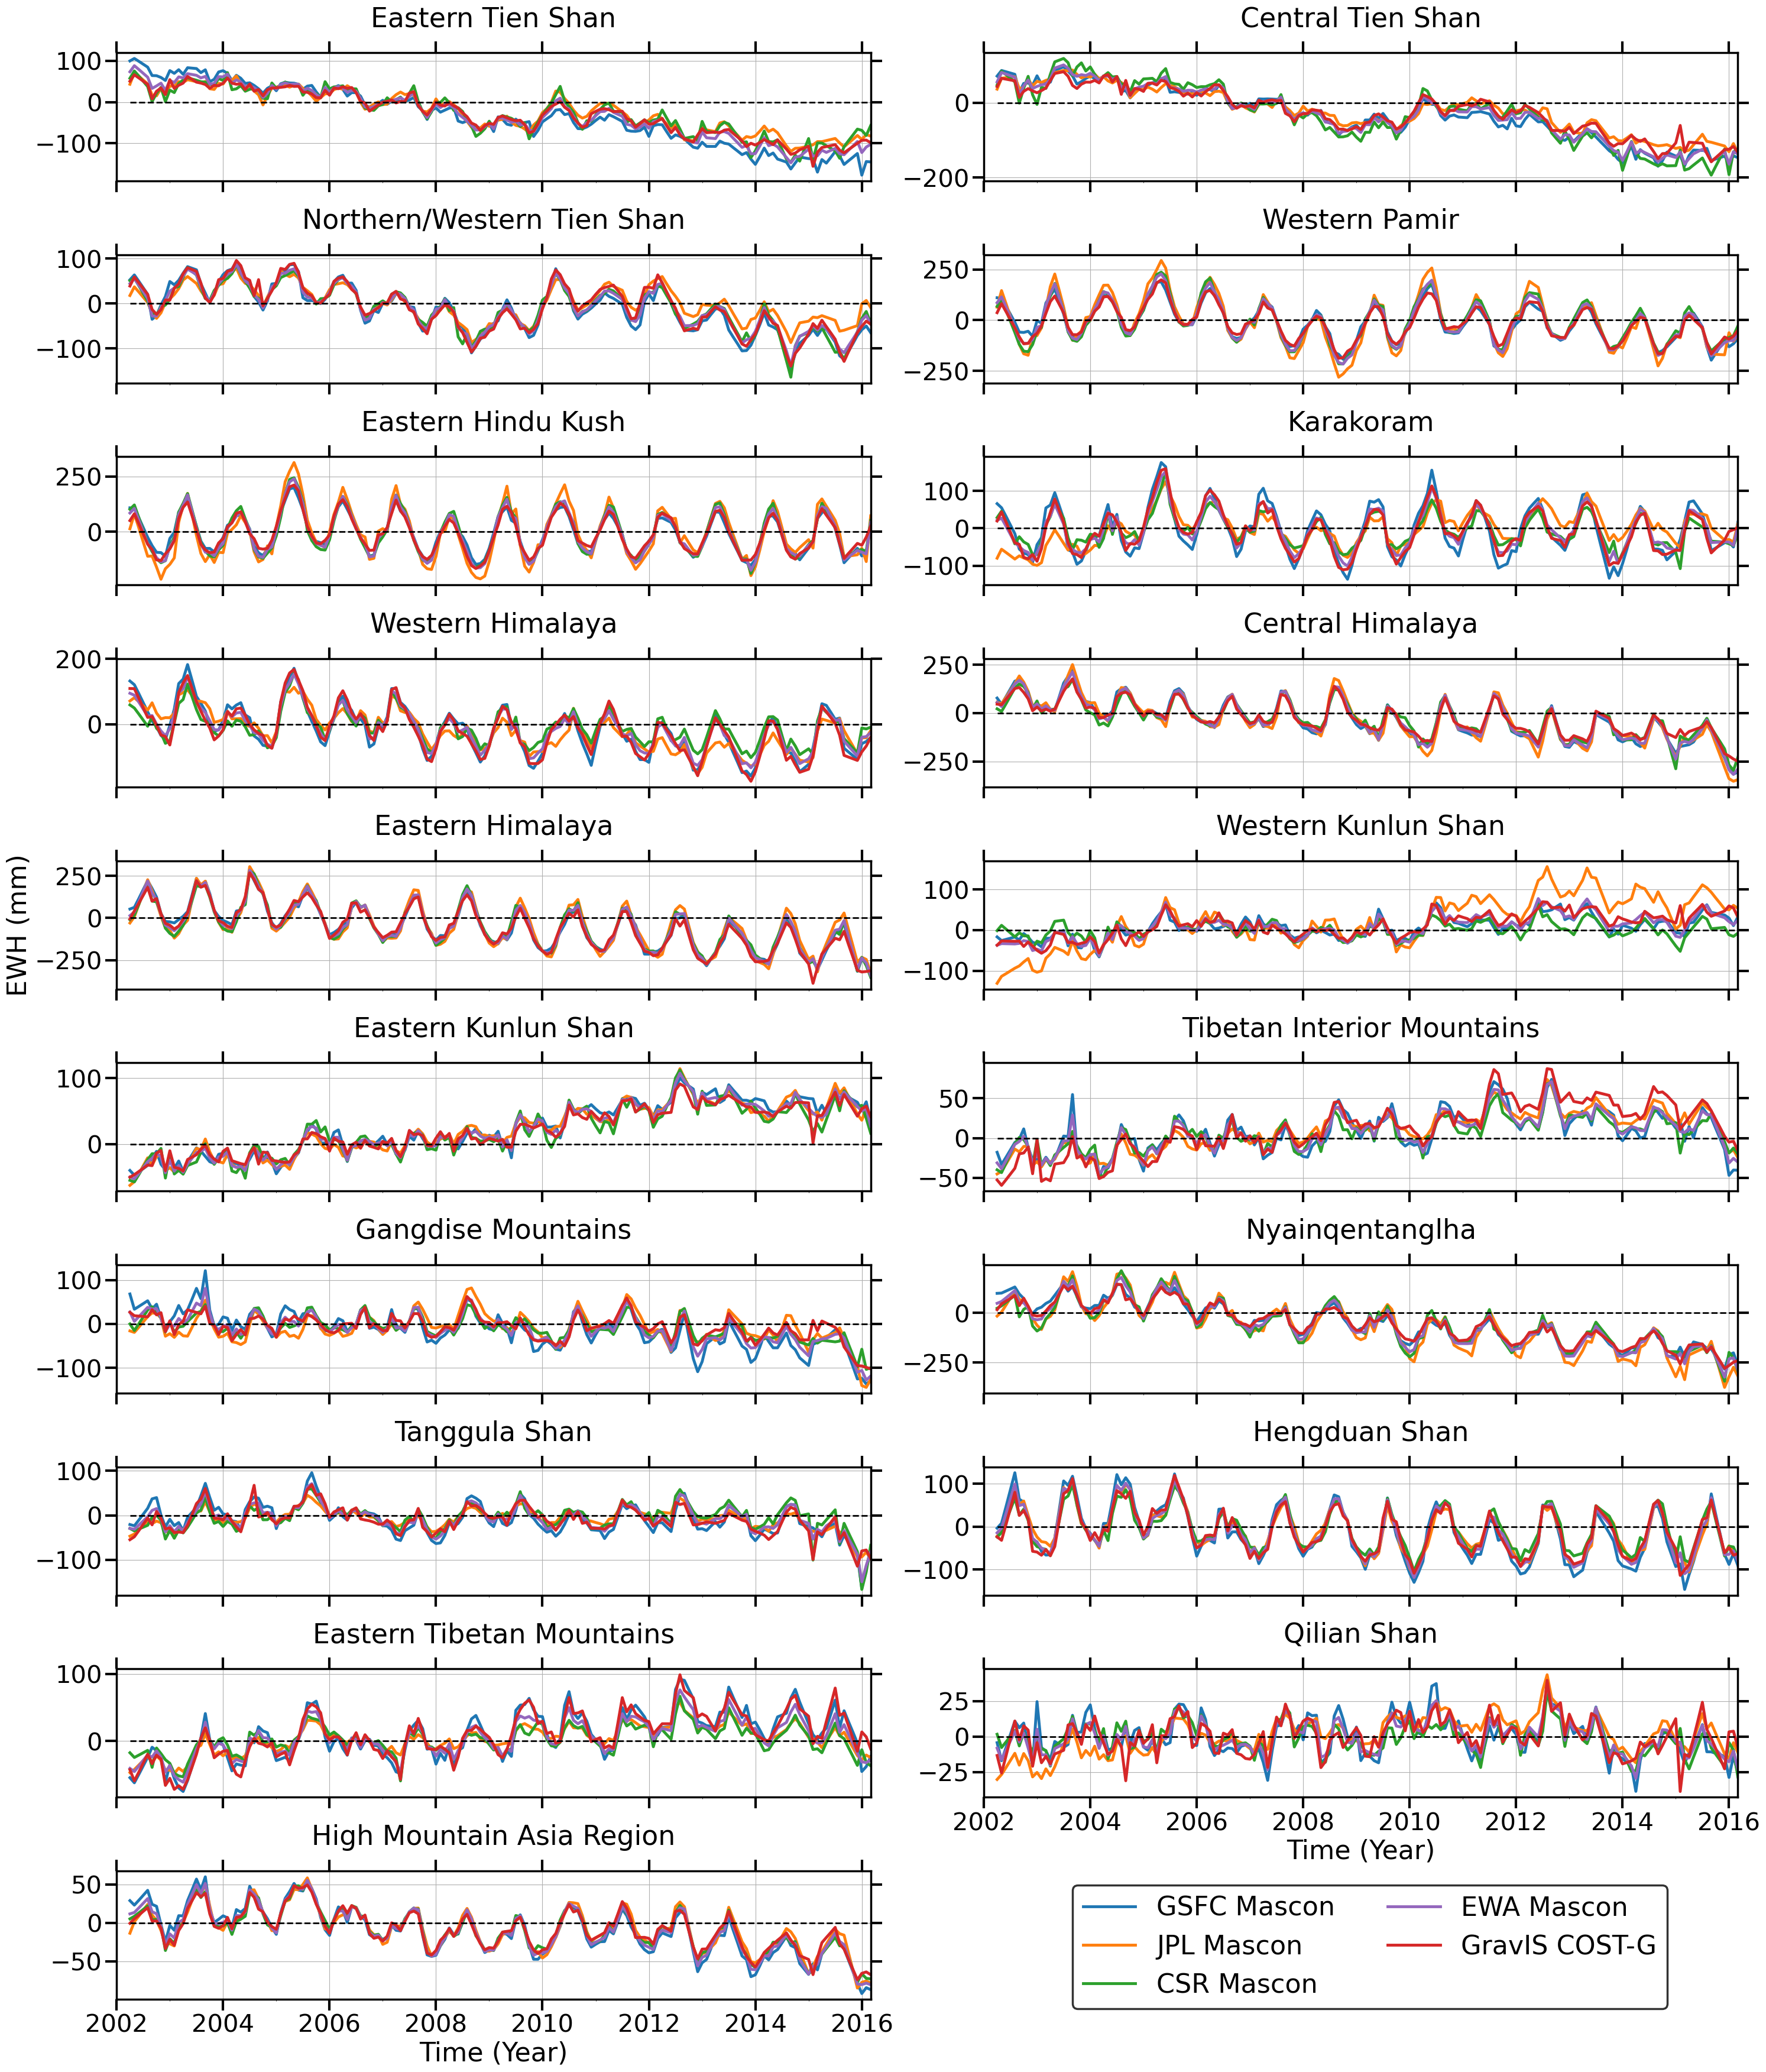

In [44]:
# Define datasets
datasets = {
    "GSFC Mascon": "D:/MSRSGI/Lab Rotation/Physical Geodesy/Python_Workspace/Organaized/Mascon/Combined/Result/Output_Data/Mascon_approach/New_GSFCMascon.csv",
    "JPL Mascon": "New_JPLMascon.csv",
    "CSR Mascon": "New_CSRMascon.csv",
    #"Average Mascon": "EnsembleAverageMascon.csv",
    "EWA Mascon": "D:/MSRSGI/Lab Rotation/Physical Geodesy/Python_Workspace/Organaized/Mascon/Combined/Result/Output_Data/Mascon_approach/New_EnsembleWeightedAverageMascon.csv",
    "GravIS COST-G": "D:/MSRSGI/Lab Rotation/Physical Geodesy/Python_Workspace/Organaized/Mascon/Combined/Result/Output_Data/COSTG/New_COSTG.csv"
}

dataset_colors = {
    "GSFC Mascon": "#1f77b4",       # Blue
    "JPL Mascon": "#ff7f0e",         # Orange
    "CSR Mascon": "#2ca02c",         # Green
    "EWA Mascon": "#9467bd",  # Purple
    "GravIS COST-G": "#d62728"     # Red
}

# Load region metadata
region_metadata = pd.DataFrame({
    'region': [
        'Eastern Hindu Kush', 'Western Himalaya', 'Eastern Himalaya', 'Central Himalaya', 'Karakoram',
        'Western Pamir', 'Northern/Western Tien Shan', 'Western Kunlun Shan', 'Nyainqentanglha', 'Gangdise Mountains', 'Hengduan Shan',
        'Tibetan Interior Mountains', 'Tanggula Shan', 'Eastern Tibetan Mountains', 'Qilian Shan', 'Eastern Kunlun Shan',
        'Eastern Tien Shan', 'Central Tien Shan', 'High Mountain Asia Region'
    ],
    'region_id': [8, 10, 12, 11, 9, 6, 4, 13, 18, 17, 20, 16, 19, 21, 22, 14, 2, 3, 23]
})
region_metadata_sorted = region_metadata.sort_values(by='region_id')
sorted_regions = region_metadata_sorted['region'].values

# Load and preprocess all datasets
dfs = {}
for name, file in datasets.items():
    df = pd.read_csv(file)
    df['time'] = pd.to_datetime(df['time'])
    df.set_index('time', inplace=True)
    dfs[name] = df[sorted_regions]  # Ensure consistent region order

# # Create colormap for datasets
# colors = plt.cm.tab10(np.linspace(0, 1, len(datasets)))

# Setup figure
fig, axes = plt.subplots(10, 2, figsize=(30, 36), sharex=True, sharey=False)
axes = axes.flatten()

# Generate x-ticks
time_index = dfs[list(datasets.keys())[0]].index
start_year = time_index.min().year
end_year = time_index.max().year
x_ticks = pd.date_range(start=f'{start_year}', end=f'{end_year}', freq='2YS')

# Plot each region with all datasets
for i, (_, row) in enumerate(region_metadata_sorted.iterrows()):
    region = row['region']
    region_id = row['region_id']
    ax = axes[i]
    
    # # Plot each dataset for current region
    # for j, (name, df) in enumerate(dfs.items()):
    #     df[region].plot(ax=ax, color=colors[j], label=name, linewidth=2)

    for name, df in dfs.items():
        df[region].plot(
            ax=ax,
            color=dataset_colors[name],
            label=name,
            linewidth=3.5
        )
    
    # ax.set_title(region, fontsize=22)
    ax.set_title(region, fontsize=33, pad=32)
    ax.grid(True)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([tick.year for tick in x_ticks], rotation=0)
    
    # ax.tick_params(axis='x', labelsize=22, direction='out', top=True, bottom=True, length=7.5, width=0.8)
    # ax.tick_params(axis='y', labelsize=22, direction='out', left=True, right=True, length=7.5, width=0.8)
    ax.tick_params(axis='x', labelsize=30, direction='out', top=True, bottom=True, length=14, width=3)
    ax.tick_params(axis='y', labelsize=30, direction='out', left=True, right=True, length=14, width=3)
    
    
    ax.hlines(0, time_index.min(), time_index.max(), colors='k', linestyles='--', linewidth=2)
    
    # # Add region ID
    # ax.text(0.95, 0.95, f"{region_id}", transform=ax.transAxes,
    #         fontsize=16, fontweight='bold', verticalalignment='top', horizontalalignment='left',
    #         bbox=dict(facecolor='white', edgecolor='black', boxstyle='round, pad=0.2', linewidth=1))

for ax in axes:   #setting rectangular box for each subplot, adjusting the width of the edge of the box
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)
        spine.set_edgecolor('black')

# Add labels and legend
axes[8].set_ylabel('EWH (mm)', fontsize=32)

axes[17].set_xlabel('Time (Year)', fontsize=32)

axes[18].set_xlabel('Time (Year)', fontsize=32)

# Make sure x-tick labels are visible on bottom row axes
axes[17].tick_params(labelbottom=True)

axes[17].xaxis.get_label().set_visible(True)

# === LEGEND PLACEMENT ===
legend = axes[18].legend(
    list(datasets.keys()),
    loc='center left',
    # bbox_to_anchor=(1.27, 0.43),  # Adjust horizontal position as needed
    bbox_to_anchor=(1.25, 0.41),  # Adjust horizontal position as needed
    ncol=2,
    fontsize=32,
    frameon=True
)
legend.get_frame().set_edgecolor('black')
legend.get_frame().set_linewidth(2.5)

axes[18].tick_params(labelbottom=True)


# fig.legend(list(datasets.keys()), loc='lower center', 
#            bbox_to_anchor=(0.52, -0.03), ncol=5, fontsize=30)

# Remove unused subplots
for j in range(len(df.columns), len(axes)):
    fig.delaxes(axes[j])

# Final adjustments
plt.tight_layout()
plt.subplots_adjust(top=0.95, wspace=0.15)
plt.savefig(r'D:/MSRSGI/Lab Rotation/Physical Geodesy/Python_Workspace/Organaized/Mascon/Combined/Result/Figures/Thesis_TimeSeries/Approaches/Mascon_approach/AllDatasetsTWSAafterGIAcorrection__timeseries_no_sharey1.png', dpi=300, bbox_inches='tight')
plt.show()

### MAP SUBPLOT AND TIME SERIES

In [45]:
gdf = gpd.read_file(r'D:/MSRSGI/Masters_thesis/Data/HMA_Region_Shapefiles/Regions_shapefiles/HMA_region_annoted_final.shp')
gdf = gdf.to_crs(epsg=4326)
gdf

,Primary_ID,Shape_Area,Area,Region_No,geometry
0,Hindu Kush,1.001511e+11,100151.057161,4,"POLYGON ((73.45169 36.98397, 73.44596 36.96573..."
1,West Himalaya,1.941335e+11,194133.501988,8,"POLYGON ((75.78745 35.3156, 75.78746 35.31561,..."
2,East Himalaya,1.656420e+11,165641.965241,12,"POLYGON ((95.22303 29.82187, 95.21352 29.80717..."
3,Central Himalaya,2.560271e+11,256027.113266,9,"POLYGON ((80.9356 30.70763, 80.98096 30.6962, ..."
4,Karakoram,8.561107e+10,85611.068729,5,"POLYGON ((75.87363 37.3118, 75.89061 37.31113,..."
5,Pamir,2.300013e+11,113753.523167,3,"POLYGON ((73.72706 40.56312, 73.79905 40.53345..."
6,West Tien Shan,2.980577e+11,191739.612580,2,"POLYGON ((82.41885 43.53144, 82.66204 43.50198..."
7,West Kun Lun,1.246661e+11,124666.068073,6,"POLYGON ((77.76954 37.37377, 78.24541 37.24774..."
8,Gangdise,1.554833e+11,155483.256729,10,"POLYGON ((79.0432 33.76314, 79.12291 33.73493,..."
9,Hengduan Shan,3.880645e+11,388064.452434,15,"POLYGON ((103.33986 29.8653, 103.51191 29.6781..."


C:\Users\sudur\AppData\Local\Temp\ipykernel_16632\200099791.py:180: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  leg = fig.legend(list(datasets.keys()), loc='lower center', bbox_to_anchor=(0.683, -0.035), ncol=2, fontsize=30)


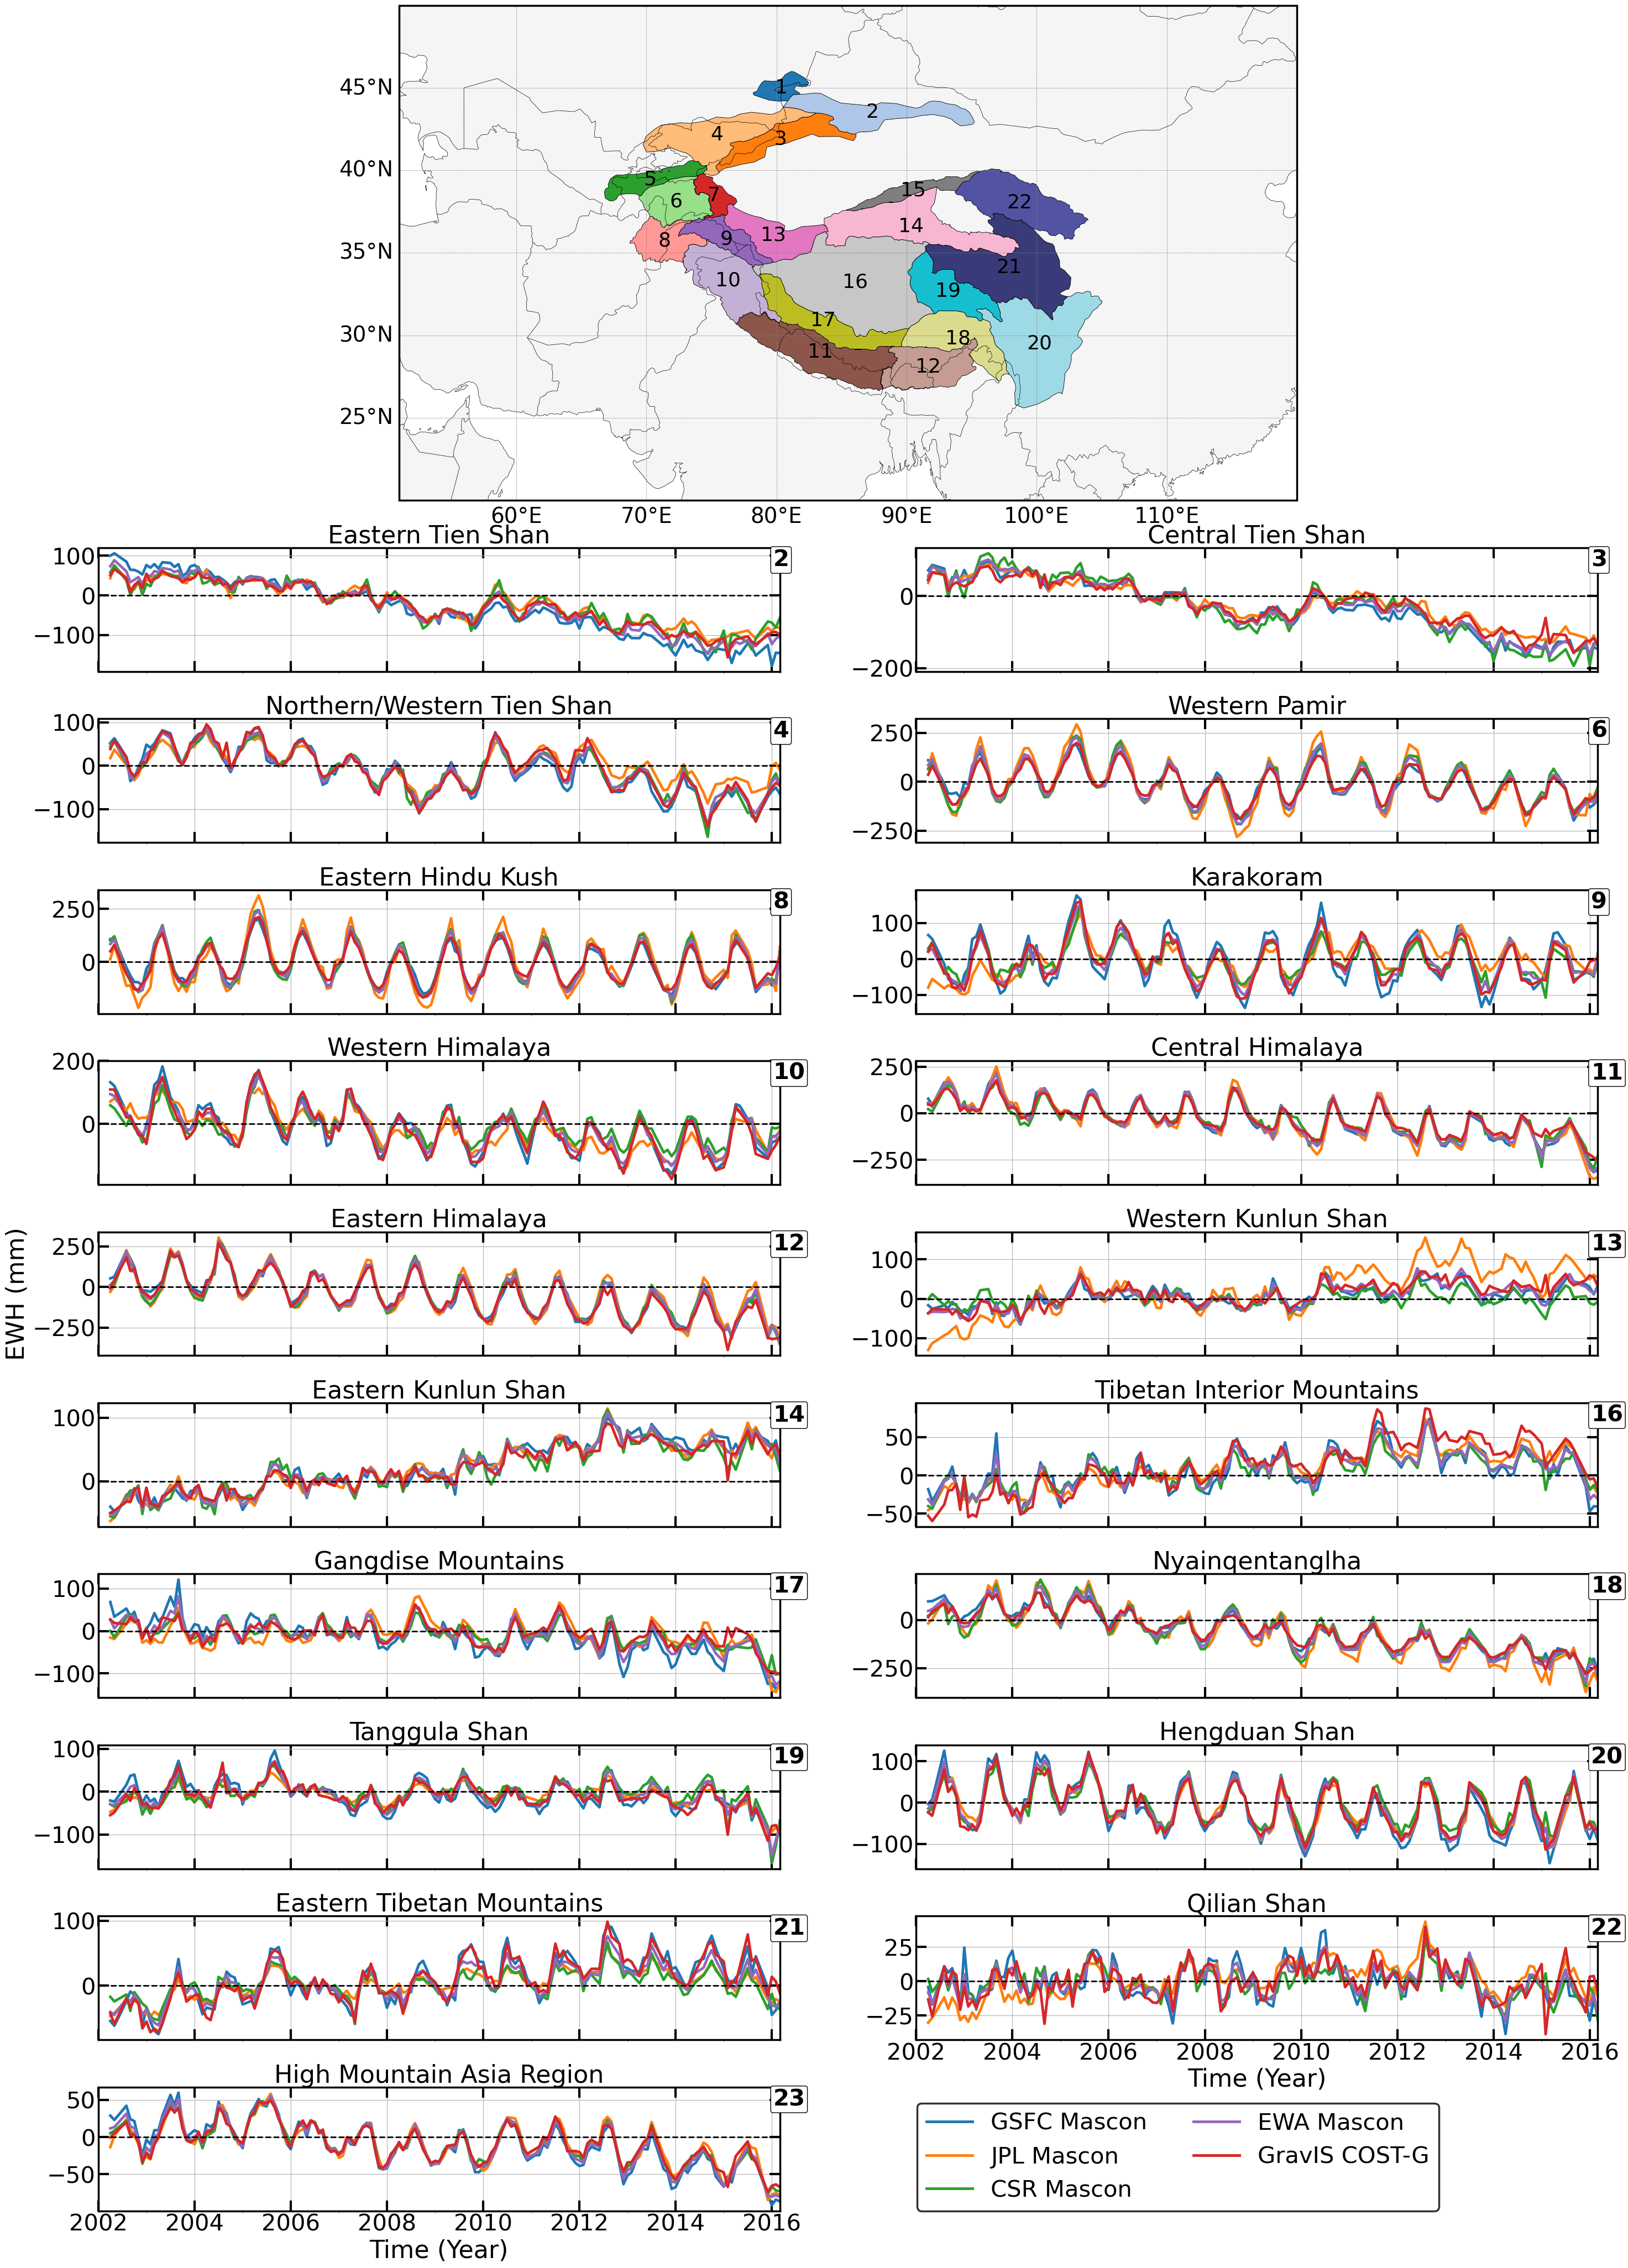

In [46]:
## 1--import package
import matplotlib.gridspec as gridspec

## 2-- Load your shapefile
gdf = gpd.read_file(r'D:\MSRSGI\Masters_thesis\Data\HMA_Region_Shapefiles\Regions_shapefiles\New folder\Updated_TotalHMA_boundary1_22.shp')
gdf = gdf.to_crs(epsg=4326)

# Define datasets
datasets = {
    "GSFC Mascon": "D:/MSRSGI/Lab Rotation/Physical Geodesy/Python_Workspace/Organaized/Mascon/Combined/Result/Output_Data/Mascon_approach/New_GSFCMascon.csv",
    "JPL Mascon": "New_JPLMascon.csv",
    "CSR Mascon": "New_CSRMascon.csv",
    #"Average Mascon": "EnsembleAverageMascon.csv",
    "EWA Mascon": "D:/MSRSGI/Lab Rotation/Physical Geodesy/Python_Workspace/Organaized/Mascon/Combined/Result/Output_Data/Mascon_approach/New_EnsembleWeightedAverageMascon.csv",
    "GravIS COST-G": "D:/MSRSGI/Lab Rotation/Physical Geodesy/Python_Workspace/Organaized/Mascon/Combined/Result/Output_Data/COSTG/New_COSTG.csv"
}

dataset_colors = {
    "GSFC Mascon": "#1f77b4",       # Blue
    "JPL Mascon": "#ff7f0e",         # Orange
    "CSR Mascon": "#2ca02c",         # Green
    "EWA Mascon": "#9467bd",  # Purple
    "GravIS COST-G": "#d62728"     # Red
}

# Load region metadata
region_metadata = pd.DataFrame({
    'region': [
        'Eastern Hindu Kush', 'Western Himalaya', 'Eastern Himalaya', 'Central Himalaya', 'Karakoram',
        'Western Pamir', 'Northern/Western Tien Shan', 'Western Kunlun Shan', 'Nyainqentanglha', 'Gangdise Mountains', 'Hengduan Shan',
        'Tibetan Interior Mountains', 'Tanggula Shan', 'Eastern Tibetan Mountains', 'Qilian Shan', 'Eastern Kunlun Shan',
        'Eastern Tien Shan', 'Central Tien Shan', 'High Mountain Asia Region'
    ],
    'region_id': [8, 10, 12, 11, 9, 6, 4, 13, 18, 17, 20, 16, 19, 21, 22, 14, 2, 3, 23]
})
region_metadata_sorted = region_metadata.sort_values(by='region_id')
sorted_regions = region_metadata_sorted['region'].values

# Load and preprocess all datasets
dfs = {}
for name, file in datasets.items():
    df = pd.read_csv(file)
    df['time'] = pd.to_datetime(df['time'])
    df.set_index('time', inplace=True)
    dfs[name] = df[sorted_regions]  # Ensure consistent region order

# Prepare color list with 22 distinct colors using matplotlib colormaps
import numpy as np
colors = list(plt.cm.tab20.colors) + list(plt.cm.tab20b.colors)  # 20 + 20 colors total
colors = colors[:22]  # select first 22 colors

# Map region_ids to colors (make sure to map from your gdf Region_No unique sorted)
unique_region_nos = sorted(gdf['Region_No'].unique())
region_color_map = {region_no: colors[i] for i, region_no in enumerate(unique_region_nos)}

##############################
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.ticker as mticker
import numpy as np

# Define tick locations - adjust as needed for your extent and desired intervals
lon_ticks = np.arange(50, 125, 10)  # longitudes from 50 to 120 every 10 degrees
lat_ticks = np.arange(20, 55, 5)    # latitudes from 20 to 50 every 5 degrees

# # Set ticks at those locations using PlateCarree coordinate system
# ax_map.set_xticks(lon_ticks, crs=ccrs.PlateCarree())
# ax_map.set_yticks(lat_ticks, crs=ccrs.PlateCarree())

ax_map.tick_params(axis='x', labelsize=30, direction='in', top=True, bottom=True, length=14, width=3)
ax_map.tick_params(axis='y', labelsize=30, direction='in', left=True, right=True, length=14, width=3)

# Use Cartopy formatters for nicer labels with degree symbols and directions
lon_formatter = LongitudeFormatter()
lat_formatter = LatitudeFormatter()

# ax_map.xaxis.set_major_formatter(lon_formatter)
# ax_map.yaxis.set_major_formatter(lat_formatter)


###############################


## 3-- Set up figure with GridSpec---
fig = plt.figure(figsize=(35, 42))
# gs = gridspec.GridSpec(9, 2, height_ratios=[3] + [1]*8)  # 1 row for map (taller), 8 for time series

gs = gridspec.GridSpec(11, 2, height_ratios=[4] + [1]*10)  # 1 row for map (taller), rest for time series


## 4--- Map subplot (top row) --
ax_map = plt.subplot(gs[0, :], projection=ccrs.PlateCarree())

# # Plot regions
# gdf.plot(column='Region_No', ax=ax_map, cmap='tab20', legend=False, edgecolor='black', linewidth=0.6)

# Plot each region separately with assigned color to control distinct colors
for region_no, data in gdf.groupby('Region_No'):
    color = region_color_map.get(region_no, '#cccccc')  # fallback gray if not found
    data.plot(ax=ax_map, facecolor=color, edgecolor='black', linewidth=0.6, label=f'Region {region_no}')
    
# ax_map.tick_params(axis='x', labelsize=30, direction='in', top=True, bottom=True, length=14, width=3)
# ax_map.tick_params(axis='y', labelsize=30, direction='in', left=True, right=True, length=14, width=3)

# Add features
ax_map.add_feature(cfeature.BORDERS, linewidth=0.5)
ax_map.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax_map.add_feature(cfeature.LAND, facecolor='#F5F5F5', zorder=-5)

# Add region numbers at centroids
for idx, row in gdf.iterrows():
    centroid = row['geometry'].centroid
    ax_map.text(centroid.x, centroid.y, str(row['Region_No']),
                fontsize=26, weight='normal', color='black',
                ha='center', va='center', transform=ccrs.PlateCarree())

ax_map.set_extent([51, 120, 20, 50], crs=ccrs.PlateCarree())
for spine in ax_map.spines.values():
        spine.set_linewidth(2.5)

# Gridlines
gl = ax_map.gridlines(draw_labels=True, linewidth=0.5, color='gray', linestyle='--')

#Set exact tick locations here for gridlines and labels
gl.xlocator = mticker.FixedLocator(np.arange(50, 125, 10))  # longitude ticks every 10 degrees
gl.ylocator = mticker.FixedLocator(np.arange(20, 55, 5)) 

gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 28, 'color': 'black'}
gl.ylabel_style = {'size': 28, 'color': 'black'}

# Optional: offset labels to prevent clipping or overlap
gl.xpadding = 8
gl.ypadding = 8


## 5---- Time series subplots (rows 1–8)

region_metadata_sorted = region_metadata.sort_values(by='region_id')
sorted_regions = region_metadata_sorted['region'].values
x_ticks = pd.date_range(start=str(time_index.min().year), end=str(time_index.max().year), freq='2YS')

for i, (_, row) in enumerate(region_metadata_sorted.iterrows()):
    row_idx = i // 2 + 1  # +1 because row 0 is the map
    col_idx = i % 2
    ax = plt.subplot(gs[row_idx, col_idx])
    region = row['region']
    region_id = row['region_id']

    # Plot each dataset for this region
    for name, df in dfs.items():
        df[region].plot(
            ax=ax,
            color=dataset_colors[name],
            label=name if i == 0 else "",  # Only label in first subplot for legend
            linewidth=3.5
        )
    ax.set_title(region, fontsize=32)
    ax.grid(True)
    ax.set_xticks(x_ticks)
    if i in [17, 18]:
        ax.set_xticklabels([tick.year for tick in x_ticks], rotation=0)
        ax.set_xlabel("Time (Year)", fontsize=32)
    else:
        ax.set_xticklabels([])
        ax.set_xlabel("")
    ax.tick_params(axis='x', labelsize=30, direction='in', top=True, bottom=True, length=14, width=3)
    ax.tick_params(axis='y', labelsize=30, direction='in', left=True, right=True, length=14, width=3)
    ax.hlines(0, time_index.min(), time_index.max(), colors='k', linestyles='--', linewidth=2)
    ax.text(0.99, 0.99, f"{region_id}", transform=ax.transAxes,
            fontsize=30, fontweight='bold', verticalalignment='top', horizontalalignment='left',
            bbox=dict(facecolor='white', edgecolor='black', boxstyle='round, pad=0.1', linewidth=1))
    # Increase subplot border width
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)
    if i == 8:
        ax.set_ylabel('EWH (mm)', fontsize=32)

## 6-- Legend and layout
leg = fig.legend(list(datasets.keys()), loc='lower center', bbox_to_anchor=(0.683, -0.035), ncol=2, fontsize=30)
leg.get_frame().set_edgecolor('black')
leg.get_frame().set_linewidth(2.5)
plt.subplots_adjust(top=0.92, bottom=-0.03, hspace=0.3)
plt.savefig(r'D:/MSRSGI/Lab Rotation/Physical Geodesy/Python_Workspace/Organaized/Mascon/Combined/Result/Figures/Thesis_TimeSeries/Approaches/Mascon_approach/RegionalAveraged_map_timeseries_allDataset.svg', dpi=500, bbox_inches='tight')
plt.show()

## The above plots are after GIA correction

--------------------
-------------------
------------------

## Undo GIA correction and do VLM Correction; first step is undo GIA correction

In [54]:
import xarray as xr

# Open the NetCDF file
gia = xr.open_dataset(r'D:\MSRSGI\Lab Rotation\Physical Geodesy\Python_Workspace\Organaized\Mascon\Combined\Result\GIA_component.nc')

# Print summary info of the dataset
gia

<xarray.Dataset> Size: 1GB
Dimensions:        (time: 247, timebound: 2, lon: 1440, lat: 720)
Coordinates:
  * time           (time) float32 988B 107.0 129.5 227.5 ... 8.567e+03 8.598e+03
  * lon            (lon) float32 6kB 0.125 0.375 0.625 ... 359.4 359.6 359.9
  * lat            (lat) float32 3kB -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
Dimensions without coordinates: timebound
Data variables:
    time_bounds    (time, timebound) float32 2kB ...
    lwe_thickness  (time, lat, lon) float32 1GB ...
Attributes: (12/59)
    Conventions:                CF-1.6, ACDD-1.3, ISO 8601
    filename:                   netcdf/CSR_GRACE_GRACE-FO_RL0603_Mascons_GIA-...
    Metadata_Conventions:       Unidata Dataset Discovery v1.0
    standard_name_vocabulary:   NetCDF Climate and Forecast (CF) Metadata Con...
    title:                      CSR GRACE and GRACE-FO MASCON RL0603M
    subtitle:                   Only GIA correction component for RL06.3 GRAC...
    ...                         ...
    user_note_3:                -
    user_note_4:                This GRACE-FO RL06.3 data is an updated versi...
    date_created:               2025-09-22T10:11:46Z
    variable:                   liquid water equivalent thickness
    label:                      RL0603rc24cE
    Mask:                       Global

In [55]:
# Open your dataset
gia = xr.open_dataset(r'D:\MSRSGI\Lab Rotation\Physical Geodesy\Python_Workspace\Organaized\Mascon\Combined\Result\GIA_component.nc')


# Convert the time coordinate to datetime64[ns]
gia['time'] = pd.to_datetime(gia.time.values, unit='D', origin='2002-01-01')

# Update the time coordinate attributes
gia['time'].attrs.update({
    'long_name': 'time',
    'standard_name': 'time',
    'axis': 'T',
    'bounds': 'time_bounds'
})

# If you want to update the time_bounds as well
if 'time_bounds' in gia.variables:
    # Reshape the time_bounds array to 1D
    time_bounds_flat = gia.time_bounds.values.flatten()
    
    # Convert to datetime
    time_bounds_datetime = pd.to_datetime(time_bounds_flat, unit='D', origin='2002-01-01')
    
    # Convert DatetimeIndex to numpy array and reshape
    time_bounds_datetime_reshaped = time_bounds_datetime.to_numpy().reshape(gia.time_bounds.shape)
    
    # Assign back to the dataset
    gia['time_bounds'] = (('time', 'nv'), time_bounds_datetime_reshaped)

# Print the updated dataset information
gia

<xarray.Dataset> Size: 1GB
Dimensions:        (time: 247, nv: 2, lon: 1440, lat: 720)
Coordinates:
  * time           (time) datetime64[ns] 2kB 2002-04-18 ... 2025-07-16T12:00:00
  * lon            (lon) float32 6kB 0.125 0.375 0.625 ... 359.4 359.6 359.9
  * lat            (lat) float32 3kB -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
Dimensions without coordinates: nv
Data variables:
    time_bounds    (time, nv) datetime64[ns] 4kB 2002-04-05 ... 2025-08-01
    lwe_thickness  (time, lat, lon) float32 1GB ...
Attributes: (12/59)
    Conventions:                CF-1.6, ACDD-1.3, ISO 8601
    filename:                   netcdf/CSR_GRACE_GRACE-FO_RL0603_Mascons_GIA-...
    Metadata_Conventions:       Unidata Dataset Discovery v1.0
    standard_name_vocabulary:   NetCDF Climate and Forecast (CF) Metadata Con...
    title:                      CSR GRACE and GRACE-FO MASCON RL0603M
    subtitle:                   Only GIA correction component for RL06.3 GRAC...
    ...                         ...
    user_note_3:                -
    user_note_4:                This GRACE-FO RL06.3 data is an updated versi...
    date_created:               2025-09-22T10:11:46Z
    variable:                   liquid water equivalent thickness
    label:                      RL0603rc24cE
    Mask:                       Global

In [56]:
# # Load your CSR mascon dataset
# data = xr.open_dataset('csr_mascon.nc')  # Replace with your file
gia = gia['lwe_thickness']     # Replace 'variable_name' with your variable

# Coarsen (aggregate) the data
gia_05 = gia.coarsen(lat=2, lon=2, boundary="trim").mean()  # Averaging

# Save the new grid if needed
gia_05.to_netcdf('gia_0.5deg.nc')

In [57]:
gia_05

<xarray.DataArray 'lwe_thickness' (time: 247, lat: 360, lon: 720)> Size: 256MB
array([[[ 0.63913524,  0.63913524,  0.63913524, ...,  0.63913524,
          0.63913524,  0.63913524],
        [ 0.7748347 ,  0.7748347 ,  0.7748347 , ...,  0.7748347 ,
          0.7748347 ,  0.7748347 ],
        [ 0.7748347 ,  0.7748347 ,  0.7748347 , ...,  0.7748347 ,
          0.7748347 ,  0.7748347 ],
        ...,
        [ 2.2024343 ,  2.2024343 ,  2.2024343 , ...,  2.2024343 ,
          2.2024343 ,  2.2024343 ],
        [ 2.2024343 ,  2.2024343 ,  2.2024343 , ...,  2.2024343 ,
          2.2024343 ,  2.2024343 ],
        [ 2.0643632 ,  2.0643632 ,  2.0643632 , ...,  2.0643632 ,
          2.0643632 ,  2.0643632 ]],

       [[ 0.63076663,  0.63076663,  0.63076663, ...,  0.63076663,
          0.63076663,  0.63076663],
        [ 0.76468927,  0.76468927,  0.76468927, ...,  0.76468927,
          0.76468927,  0.76468927],
        [ 0.76468927,  0.76468927,  0.76468927, ...,  0.76468927,
          0.76468927,  0.76468927],
...
        [-8.640626  , -8.640626  , -8.640626  , ..., -8.640626  ,
         -8.640626  , -8.640626  ],
        [-8.640626  , -8.640626  , -8.640626  , ..., -8.640626  ,
         -8.640626  , -8.640626  ],
        [-8.098944  , -8.098944  , -8.098944  , ..., -8.098944  ,
         -8.098944  , -8.098944  ]],

       [[-2.5188098 , -2.5188098 , -2.5188098 , ..., -2.5188098 ,
         -2.5188098 , -2.5188098 ],
        [-3.0535965 , -3.0535965 , -3.0535965 , ..., -3.0535965 ,
         -3.0535965 , -3.0535965 ],
        [-3.0535965 , -3.0535965 , -3.0535965 , ..., -3.0535965 ,
         -3.0535965 , -3.0535965 ],
        ...,
        [-8.679718  , -8.679718  , -8.679718  , ..., -8.679718  ,
         -8.679718  , -8.679718  ],
        [-8.679718  , -8.679718  , -8.679718  , ..., -8.679718  ,
         -8.679718  , -8.679718  ],
        [-8.135585  , -8.135585  , -8.135585  , ..., -8.135585  ,
         -8.135585  , -8.135585  ]]], shape=(247, 360, 720), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 2kB 2002-04-18 ... 2025-07-16T12:00:00
  * lon      (lon) float32 3kB 0.25 0.75 1.25 1.75 ... 358.2 358.8 359.2 359.8
  * lat      (lat) float32 1kB -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
Attributes:
    grid_mapping:   WGS84
    standard_name:  Liquid_Water_Equivalent_Thickness
    long_name:      Liquid_Water_Equivalent_Thickness
    Units:          cm

In [59]:
# Assume `ds` is your xarray dataset
ds_gia = gia_05  # Replace with your actual dataset

# Shift latitude and longitude
shifted_lon = (ds_gia['lon'] - 0.25) % 360  # Wrap around [0, 360)
shifted_lat = ds_gia['lat'] - 0.25

# Update the dataset with the corrected coordinates
corrected_ds_gia = ds_gia.copy()
corrected_ds_gia = corrected_ds_gia.assign_coords(lon=shifted_lon, lat=shifted_lat)

# Sort longitude to ensure proper ordering after the shift
corrected_ds_gia = corrected_ds_gia.sortby('lon')

# Display the corrected dataset
corrected_ds_gia

<xarray.DataArray 'lwe_thickness' (time: 247, lat: 360, lon: 720)> Size: 256MB
array([[[ 0.63913524,  0.63913524,  0.63913524, ...,  0.63913524,
          0.63913524,  0.63913524],
        [ 0.7748347 ,  0.7748347 ,  0.7748347 , ...,  0.7748347 ,
          0.7748347 ,  0.7748347 ],
        [ 0.7748347 ,  0.7748347 ,  0.7748347 , ...,  0.7748347 ,
          0.7748347 ,  0.7748347 ],
        ...,
        [ 2.2024343 ,  2.2024343 ,  2.2024343 , ...,  2.2024343 ,
          2.2024343 ,  2.2024343 ],
        [ 2.2024343 ,  2.2024343 ,  2.2024343 , ...,  2.2024343 ,
          2.2024343 ,  2.2024343 ],
        [ 2.0643632 ,  2.0643632 ,  2.0643632 , ...,  2.0643632 ,
          2.0643632 ,  2.0643632 ]],

       [[ 0.63076663,  0.63076663,  0.63076663, ...,  0.63076663,
          0.63076663,  0.63076663],
        [ 0.76468927,  0.76468927,  0.76468927, ...,  0.76468927,
          0.76468927,  0.76468927],
        [ 0.76468927,  0.76468927,  0.76468927, ...,  0.76468927,
          0.76468927,  0.76468927],
...
        [-8.640626  , -8.640626  , -8.640626  , ..., -8.640626  ,
         -8.640626  , -8.640626  ],
        [-8.640626  , -8.640626  , -8.640626  , ..., -8.640626  ,
         -8.640626  , -8.640626  ],
        [-8.098944  , -8.098944  , -8.098944  , ..., -8.098944  ,
         -8.098944  , -8.098944  ]],

       [[-2.5188098 , -2.5188098 , -2.5188098 , ..., -2.5188098 ,
         -2.5188098 , -2.5188098 ],
        [-3.0535965 , -3.0535965 , -3.0535965 , ..., -3.0535965 ,
         -3.0535965 , -3.0535965 ],
        [-3.0535965 , -3.0535965 , -3.0535965 , ..., -3.0535965 ,
         -3.0535965 , -3.0535965 ],
        ...,
        [-8.679718  , -8.679718  , -8.679718  , ..., -8.679718  ,
         -8.679718  , -8.679718  ],
        [-8.679718  , -8.679718  , -8.679718  , ..., -8.679718  ,
         -8.679718  , -8.679718  ],
        [-8.135585  , -8.135585  , -8.135585  , ..., -8.135585  ,
         -8.135585  , -8.135585  ]]], shape=(247, 360, 720), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 2kB 2002-04-18 ... 2025-07-16T12:00:00
  * lon      (lon) float32 3kB 0.0 0.5 1.0 1.5 2.0 ... 358.0 358.5 359.0 359.5
  * lat      (lat) float32 1kB -90.0 -89.5 -89.0 -88.5 ... 88.0 88.5 89.0 89.5
Attributes:
    grid_mapping:   WGS84
    standard_name:  Liquid_Water_Equivalent_Thickness
    long_name:      Liquid_Water_Equivalent_Thickness
    Units:          cm

In [60]:
# Select the time range from April 2002 to April 2022
subset_gia_halfdegree_gms = corrected_ds_gia.sel(time=slice("2002-04", "2016-03"))
subset_gia_halfdegree_gms

<xarray.DataArray 'lwe_thickness' (time: 152, lat: 360, lon: 720)> Size: 158MB
array([[[ 0.63913524,  0.63913524,  0.63913524, ...,  0.63913524,
          0.63913524,  0.63913524],
        [ 0.7748347 ,  0.7748347 ,  0.7748347 , ...,  0.7748347 ,
          0.7748347 ,  0.7748347 ],
        [ 0.7748347 ,  0.7748347 ,  0.7748347 , ...,  0.7748347 ,
          0.7748347 ,  0.7748347 ],
        ...,
        [ 2.2024343 ,  2.2024343 ,  2.2024343 , ...,  2.2024343 ,
          2.2024343 ,  2.2024343 ],
        [ 2.2024343 ,  2.2024343 ,  2.2024343 , ...,  2.2024343 ,
          2.2024343 ,  2.2024343 ],
        [ 2.0643632 ,  2.0643632 ,  2.0643632 , ...,  2.0643632 ,
          2.0643632 ,  2.0643632 ]],

       [[ 0.63076663,  0.63076663,  0.63076663, ...,  0.63076663,
          0.63076663,  0.63076663],
        [ 0.76468927,  0.76468927,  0.76468927, ...,  0.76468927,
          0.76468927,  0.76468927],
        [ 0.76468927,  0.76468927,  0.76468927, ...,  0.76468927,
          0.76468927,  0.76468927],
...
        [-4.270078  , -4.270078  , -4.270078  , ..., -4.270078  ,
         -4.270078  , -4.270078  ],
        [-4.270078  , -4.270078  , -4.270078  , ..., -4.270078  ,
         -4.270078  , -4.270078  ],
        [-4.002386  , -4.002386  , -4.002386  , ..., -4.002386  ,
         -4.002386  , -4.002386  ]],

       [[-1.2508711 , -1.2508711 , -1.2508711 , ..., -1.2508711 ,
         -1.2508711 , -1.2508711 ],
        [-1.5164524 , -1.5164524 , -1.5164524 , ..., -1.5164524 ,
         -1.5164524 , -1.5164524 ],
        [-1.5164524 , -1.5164524 , -1.5164524 , ..., -1.5164524 ,
         -1.5164524 , -1.5164524 ],
        ...,
        [-4.310451  , -4.310451  , -4.310451  , ..., -4.310451  ,
         -4.310451  , -4.310451  ],
        [-4.310451  , -4.310451  , -4.310451  , ..., -4.310451  ,
         -4.310451  , -4.310451  ],
        [-4.0402284 , -4.0402284 , -4.0402284 , ..., -4.0402284 ,
         -4.0402284 , -4.0402284 ]]], shape=(152, 360, 720), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1kB 2002-04-18 ... 2016-03-16T12:00:00
  * lon      (lon) float32 3kB 0.0 0.5 1.0 1.5 2.0 ... 358.0 358.5 359.0 359.5
  * lat      (lat) float32 1kB -90.0 -89.5 -89.0 -88.5 ... 88.0 88.5 89.0 89.5
Attributes:
    grid_mapping:   WGS84
    standard_name:  Liquid_Water_Equivalent_Thickness
    long_name:      Liquid_Water_Equivalent_Thickness
    Units:          cm

In [61]:
gia_lwe_thickness = subset_gia_halfdegree_gms
gia_lwe_thickness = gia_lwe_thickness.resample(time='M').mean().interpolate_na(dim='time')
gia_lwe_thickness

C:\Users\sudur\miniconda3\envs\Thesis\Lib\site-packages\xarray\groupers.py:498: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


<xarray.DataArray 'lwe_thickness' (time: 168, lat: 360, lon: 720)> Size: 174MB
array([[[ 0.63913524,  0.63913524,  0.63913524, ...,  0.63913524,
          0.63913524,  0.63913524],
        [ 0.7748347 ,  0.7748347 ,  0.7748347 , ...,  0.7748347 ,
          0.7748347 ,  0.7748347 ],
        [ 0.7748347 ,  0.7748347 ,  0.7748347 , ...,  0.7748347 ,
          0.7748347 ,  0.7748347 ],
        ...,
        [ 2.2024343 ,  2.2024343 ,  2.2024343 , ...,  2.2024343 ,
          2.2024343 ,  2.2024343 ],
        [ 2.2024343 ,  2.2024343 ,  2.2024343 , ...,  2.2024343 ,
          2.2024343 ,  2.2024343 ],
        [ 2.0643632 ,  2.0643632 ,  2.0643632 , ...,  2.0643632 ,
          2.0643632 ,  2.0643632 ]],

       [[ 0.63076663,  0.63076663,  0.63076663, ...,  0.63076663,
          0.63076663,  0.63076663],
        [ 0.76468927,  0.76468927,  0.76468927, ...,  0.76468927,
          0.76468927,  0.76468927],
        [ 0.76468927,  0.76468927,  0.76468927, ...,  0.76468927,
          0.76468927,  0.76468927],
...
        [-4.270078  , -4.270078  , -4.270078  , ..., -4.270078  ,
         -4.270078  , -4.270078  ],
        [-4.270078  , -4.270078  , -4.270078  , ..., -4.270078  ,
         -4.270078  , -4.270078  ],
        [-4.002386  , -4.002386  , -4.002386  , ..., -4.002386  ,
         -4.002386  , -4.002386  ]],

       [[-1.2508711 , -1.2508711 , -1.2508711 , ..., -1.2508711 ,
         -1.2508711 , -1.2508711 ],
        [-1.5164524 , -1.5164524 , -1.5164524 , ..., -1.5164524 ,
         -1.5164524 , -1.5164524 ],
        [-1.5164524 , -1.5164524 , -1.5164524 , ..., -1.5164524 ,
         -1.5164524 , -1.5164524 ],
        ...,
        [-4.310451  , -4.310451  , -4.310451  , ..., -4.310451  ,
         -4.310451  , -4.310451  ],
        [-4.310451  , -4.310451  , -4.310451  , ..., -4.310451  ,
         -4.310451  , -4.310451  ],
        [-4.0402284 , -4.0402284 , -4.0402284 , ..., -4.0402284 ,
         -4.0402284 , -4.0402284 ]]], shape=(168, 360, 720), dtype=float32)
Coordinates:
  * lon      (lon) float32 3kB 0.0 0.5 1.0 1.5 2.0 ... 358.0 358.5 359.0 359.5
  * lat      (lat) float32 1kB -90.0 -89.5 -89.0 -88.5 ... 88.0 88.5 89.0 89.5
  * time     (time) datetime64[ns] 1kB 2002-04-30 2002-05-31 ... 2016-03-31
Attributes:
    grid_mapping:   WGS84
    standard_name:  Liquid_Water_Equivalent_Thickness
    long_name:      Liquid_Water_Equivalent_Thickness
    Units:          cm

In [70]:
# Assuming gia_lwe_thickness is your DataArray in cm
gia_lwe_thickness_meter = gia_lwe_thickness / 100.0

# Optional: update the units attribute to reflect the new unit (meters)
gia_lwe_thickness_meter.attrs['units'] = 'm'
gia_lwe_thickness_meter

<xarray.DataArray 'lwe_thickness' (time: 168, lat: 360, lon: 720)> Size: 174MB
array([[[ 0.00639135,  0.00639135,  0.00639135, ...,  0.00639135,
          0.00639135,  0.00639135],
        [ 0.00774835,  0.00774835,  0.00774835, ...,  0.00774835,
          0.00774835,  0.00774835],
        [ 0.00774835,  0.00774835,  0.00774835, ...,  0.00774835,
          0.00774835,  0.00774835],
        ...,
        [ 0.02202434,  0.02202434,  0.02202434, ...,  0.02202434,
          0.02202434,  0.02202434],
        [ 0.02202434,  0.02202434,  0.02202434, ...,  0.02202434,
          0.02202434,  0.02202434],
        [ 0.02064363,  0.02064363,  0.02064363, ...,  0.02064363,
          0.02064363,  0.02064363]],

       [[ 0.00630767,  0.00630767,  0.00630767, ...,  0.00630767,
          0.00630767,  0.00630767],
        [ 0.00764689,  0.00764689,  0.00764689, ...,  0.00764689,
          0.00764689,  0.00764689],
        [ 0.00764689,  0.00764689,  0.00764689, ...,  0.00764689,
          0.00764689,  0.00764689],
...
        [-0.04270078, -0.04270078, -0.04270078, ..., -0.04270078,
         -0.04270078, -0.04270078],
        [-0.04270078, -0.04270078, -0.04270078, ..., -0.04270078,
         -0.04270078, -0.04270078],
        [-0.04002386, -0.04002386, -0.04002386, ..., -0.04002386,
         -0.04002386, -0.04002386]],

       [[-0.01250871, -0.01250871, -0.01250871, ..., -0.01250871,
         -0.01250871, -0.01250871],
        [-0.01516452, -0.01516452, -0.01516452, ..., -0.01516452,
         -0.01516452, -0.01516452],
        [-0.01516452, -0.01516452, -0.01516452, ..., -0.01516452,
         -0.01516452, -0.01516452],
        ...,
        [-0.04310451, -0.04310451, -0.04310451, ..., -0.04310451,
         -0.04310451, -0.04310451],
        [-0.04310451, -0.04310451, -0.04310451, ..., -0.04310451,
         -0.04310451, -0.04310451],
        [-0.04040228, -0.04040228, -0.04040228, ..., -0.04040228,
         -0.04040228, -0.04040228]]], shape=(168, 360, 720), dtype=float32)
Coordinates:
  * lon      (lon) float32 3kB 0.0 0.5 1.0 1.5 2.0 ... 358.0 358.5 359.0 359.5
  * lat      (lat) float32 1kB -90.0 -89.5 -89.0 -88.5 ... 88.0 88.5 89.0 89.5
  * time     (time) datetime64[ns] 1kB 2002-04-30 2002-05-31 ... 2016-03-31
Attributes:
    units:    m

In [72]:
gia_lwe_thickness_meter.to_netcdf('GIA_component_halfdegree_meter.nc')

In [73]:
GIA_component_halfdegree = xr.open_dataset('GIA_component_halfdegree_meter.nc')
GIA_component_halfdegree

<xarray.Dataset> Size: 174MB
Dimensions:        (lon: 720, lat: 360, time: 168)
Coordinates:
  * lon            (lon) float32 3kB 0.0 0.5 1.0 1.5 ... 358.0 358.5 359.0 359.5
  * lat            (lat) float32 1kB -90.0 -89.5 -89.0 -88.5 ... 88.5 89.0 89.5
  * time           (time) datetime64[ns] 1kB 2002-04-30 ... 2016-03-31
Data variables:
    lwe_thickness  (time, lat, lon) float32 174MB ...

---------
----------

In [74]:
weighted_mean_mascon = xr.open_dataset(r'D:\MSRSGI\Lab Rotation\Physical Geodesy\Python_Workspace\Organaized\Mascon\Combined\Result\Output_Data\Mascon_approach\VCE_EWA_mascon_pdsmc_tws1_meter_attribute2.nc')
weighted_mean_mascon

<xarray.Dataset> Size: 348MB
Dimensions:        (lon: 720, lat: 360, time: 168)
Coordinates:
  * lon            (lon) float64 6kB 0.0 0.5 1.0 1.5 ... 358.0 358.5 359.0 359.5
  * lat            (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 88.5 89.0 89.5
  * time           (time) datetime64[ns] 1kB 2002-04-30 ... 2016-03-31
Data variables:
    lwe_thickness  (time, lat, lon) float64 348MB ...

------

In [78]:
weighted_mean_mascon['lwe_thickness']

<xarray.DataArray 'lwe_thickness' (time: 168, lat: 360, lon: 720)> Size: 348MB
array([[[-0.064911, -0.064854, ..., -0.065023, -0.064967],
        [-0.065413, -0.065292, ..., -0.065661, -0.065536],
        ...,
        [-0.015367, -0.015367, ..., -0.017518, -0.017518],
        [-0.017452, -0.017452, ..., -0.017452, -0.017452]],

       [[-0.061656, -0.061601, ..., -0.061768, -0.061712],
        [-0.061248, -0.061127, ..., -0.061496, -0.061371],
        ...,
        [-0.03102 , -0.03102 , ..., -0.033028, -0.033028],
        [-0.029595, -0.029595, ..., -0.029595, -0.029595]],

       ...,

       [[ 0.104   ,  0.103928, ...,  0.104142,  0.104071],
        [ 0.100089,  0.099954, ...,  0.100366,  0.100226],
        ...,
        [-0.02146 , -0.02146 , ..., -0.017441, -0.017441],
        [-0.013297, -0.013297, ..., -0.013297, -0.013297]],

       [[ 0.111797,  0.111706, ...,  0.111978,  0.111888],
        [ 0.117166,  0.116988, ...,  0.117526,  0.117345],
        ...,
        [-0.026041, -0.026041, ..., -0.023429, -0.023429],
        [-0.015847, -0.015847, ..., -0.015847, -0.015847]]],
      shape=(168, 360, 720))
Coordinates:
  * lon      (lon) float64 6kB 0.0 0.5 1.0 1.5 2.0 ... 358.0 358.5 359.0 359.5
  * lat      (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 88.0 88.5 89.0 89.5
  * time     (time) datetime64[ns] 1kB 2002-04-30 2002-05-31 ... 2016-03-31
Attributes:
    grid_mapping:   WGS84
    standard_name:  Liquid_Water_Equivalent_Thickness
    long_name:      Liquid_Water_Equivalent_Thickness
    units:          meters

In [79]:
GIA_component_halfdegree['lwe_thickness']

<xarray.DataArray 'lwe_thickness' (time: 168, lat: 360, lon: 720)> Size: 174MB
array([[[ 0.006391,  0.006391, ...,  0.006391,  0.006391],
        [ 0.007748,  0.007748, ...,  0.007748,  0.007748],
        ...,
        [ 0.022024,  0.022024, ...,  0.022024,  0.022024],
        [ 0.020644,  0.020644, ...,  0.020644,  0.020644]],

       [[ 0.006308,  0.006308, ...,  0.006308,  0.006308],
        [ 0.007647,  0.007647, ...,  0.007647,  0.007647],
        ...,
        [ 0.021736,  0.021736, ...,  0.021736,  0.021736],
        [ 0.020373,  0.020373, ...,  0.020373,  0.020373]],

       ...,

       [[-0.012392, -0.012392, ..., -0.012392, -0.012392],
        [-0.015022, -0.015022, ..., -0.015022, -0.015022],
        ...,
        [-0.042701, -0.042701, ..., -0.042701, -0.042701],
        [-0.040024, -0.040024, ..., -0.040024, -0.040024]],

       [[-0.012509, -0.012509, ..., -0.012509, -0.012509],
        [-0.015165, -0.015165, ..., -0.015165, -0.015165],
        ...,
        [-0.043105, -0.043105, ..., -0.043105, -0.043105],
        [-0.040402, -0.040402, ..., -0.040402, -0.040402]]],
      shape=(168, 360, 720), dtype=float32)
Coordinates:
  * lon      (lon) float32 3kB 0.0 0.5 1.0 1.5 2.0 ... 358.0 358.5 359.0 359.5
  * lat      (lat) float32 1kB -90.0 -89.5 -89.0 -88.5 ... 88.0 88.5 89.0 89.5
  * time     (time) datetime64[ns] 1kB 2002-04-30 2002-05-31 ... 2016-03-31
Attributes:
    units:    m

In [81]:
EWA_without_solid_earth = (weighted_mean_mascon['lwe_thickness'] + GIA_component_halfdegree['lwe_thickness'])
# Optionally reconstruct DataArray after subtraction:
EWA_without_solid_earth_xr = xr.DataArray(
    EWA_without_solid_earth,
    coords=weighted_mean_mascon['lwe_thickness'].coords,
    dims=weighted_mean_mascon['lwe_thickness'].dims,
    attrs=weighted_mean_mascon['lwe_thickness'].attrs
)
EWA_without_solid_earth_xr

<xarray.DataArray 'lwe_thickness' (time: 168, lat: 360, lon: 720)> Size: 348MB
array([[[-0.05851929, -0.05846299, -0.05840664, ..., -0.05868797,
         -0.05863178, -0.05857555],
        [-0.05766506, -0.05754374, -0.05742396, ..., -0.05803784,
         -0.05791216, -0.05778789],
        [-0.04631955, -0.04615488, -0.04599479, ..., -0.0468404 ,
         -0.04666239, -0.04648875],
        ...,
        [ 0.00665693,  0.00665693,  0.00665693, ...,  0.00450631,
          0.00450631,  0.00450631],
        [ 0.00665693,  0.00665693,  0.00665693, ...,  0.00450631,
          0.00450631,  0.00450631],
        [ 0.0031915 ,  0.0031915 ,  0.0031915 , ...,  0.0031915 ,
          0.0031915 ,  0.0031915 ]],

       [[-0.05534861, -0.05529291, -0.05523718, ..., -0.0555157 ,
         -0.05546001, -0.05540431],
        [-0.05360072, -0.05348014, -0.05336215, ..., -0.0539775 ,
         -0.05384945, -0.05372384],
        [-0.0415264 , -0.04135148, -0.04118277, ..., -0.04208764,
         -0.04189457, -0.04170746],
...
        [-0.06416073, -0.06416073, -0.06416073, ..., -0.06014142,
         -0.06014142, -0.06014142],
        [-0.06416073, -0.06416073, -0.06416073, ..., -0.06014142,
         -0.06014142, -0.06014142],
        [-0.05332044, -0.05332044, -0.05332044, ..., -0.05332044,
         -0.05332044, -0.05332044]],

       [[ 0.09928849,  0.09919729,  0.09910541, ...,  0.09955865,
          0.09946916,  0.09937912],
        [ 0.10200119,  0.10182332,  0.10164688, ...,  0.10254298,
          0.10236107,  0.10218045],
        [ 0.08339246,  0.08318055,  0.0829772 , ...,  0.08407943,
          0.08384193,  0.08361292],
        ...,
        [-0.06914525, -0.06914525, -0.06914525, ..., -0.06653316,
         -0.06653316, -0.06653316],
        [-0.06914525, -0.06914525, -0.06914525, ..., -0.06653316,
         -0.06653316, -0.06653316],
        [-0.05624954, -0.05624954, -0.05624954, ..., -0.05624954,
         -0.05624954, -0.05624954]]], shape=(168, 360, 720))
Coordinates:
  * lon      (lon) float64 6kB 0.0 0.5 1.0 1.5 2.0 ... 358.0 358.5 359.0 359.5
  * lat      (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 88.0 88.5 89.0 89.5
  * time     (time) datetime64[ns] 1kB 2002-04-30 2002-05-31 ... 2016-03-31
Attributes:
    grid_mapping:   WGS84
    standard_name:  Liquid_Water_Equivalent_Thickness
    long_name:      Liquid_Water_Equivalent_Thickness
    units:          meters

In [82]:
EWA_without_solid_earth_xr.to_netcdf('EWA_without_solid_earth_Meaning_GRACE_only_signal.nc')

In [98]:
# weighted_mean_mascon['lwe_thickness']

## Above is the xarray data array without any solid Earth signal correction
## You can use this file to determine the GRACE only trend, like how it is determined in the paper: https://agupubs.onlinelibrary.wiley.com/doi/10.1029/2024JF008182 (look at the tables before discussion)

-------

In [86]:
weighted_mean_mascon

<xarray.Dataset> Size: 348MB
Dimensions:        (lon: 720, lat: 360, time: 168)
Coordinates:
  * lon            (lon) float64 6kB 0.0 0.5 1.0 1.5 ... 358.0 358.5 359.0 359.5
  * lat            (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 88.5 89.0 89.5
  * time           (time) datetime64[ns] 1kB 2002-04-30 ... 2016-03-31
Data variables:
    lwe_thickness  (time, lat, lon) float64 348MB -0.06491 -0.06485 ... -0.01585

In [103]:
gridded = weighted_mean_mascon.lwe_thickness.isel(time=0)

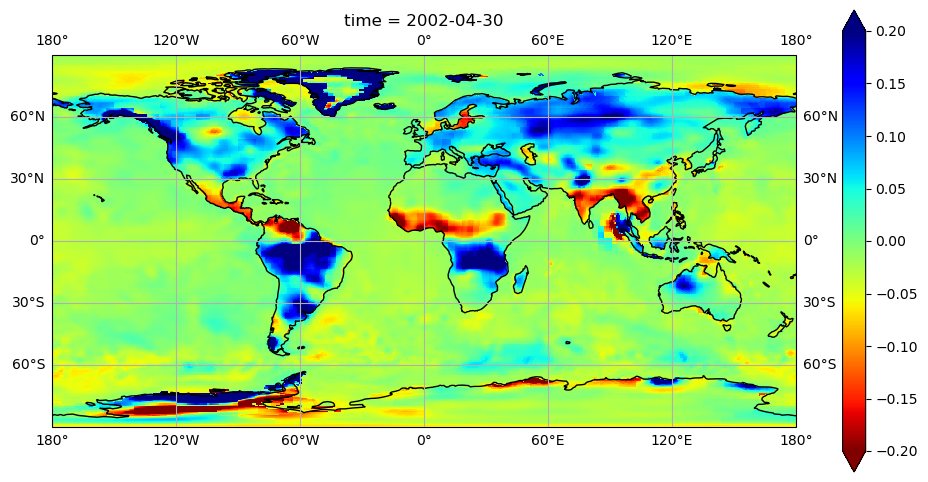

In [110]:
# Create figure and map projection (PlateCarree is lat/lon)
fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add coastlines and gridlines for context
ax.coastlines()
ax.gridlines(draw_labels=True)

# Plot the DataArray using pcolormesh with PlateCarree transform
im = gridded.plot.pcolormesh(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='jet_r',  # diverging colormap, or RdBu_r
    vmin=-0.2,   # minimum value for colormap
    vmax=0.2,
    add_colorbar=True,
    cbar_kwargs={"label": gridded.attrs.get('description', '')}
)

# # Overlay the shapefile boundary
# for geom in hma_boundary.geometry:
#     ax.add_geometries([geom], crs=ccrs.PlateCarree(), edgecolor='black', linewidth=1.5, facecolor='none')

# plt.title("Linear Trend of TWS Anomaly (mm w.e/year)")
plt.show()

## Analyzing the TWS after truncation to determine the contemporary_loading_vlm_time_series

In [87]:
mascon_approach_tws = weighted_mean_mascon['lwe_thickness']
mascon_approach_tws

<xarray.DataArray 'lwe_thickness' (time: 168, lat: 360, lon: 720)> Size: 348MB
array([[[-0.064911, -0.064854, ..., -0.065023, -0.064967],
        [-0.065413, -0.065292, ..., -0.065661, -0.065536],
        ...,
        [-0.015367, -0.015367, ..., -0.017518, -0.017518],
        [-0.017452, -0.017452, ..., -0.017452, -0.017452]],

       [[-0.061656, -0.061601, ..., -0.061768, -0.061712],
        [-0.061248, -0.061127, ..., -0.061496, -0.061371],
        ...,
        [-0.03102 , -0.03102 , ..., -0.033028, -0.033028],
        [-0.029595, -0.029595, ..., -0.029595, -0.029595]],

       ...,

       [[ 0.104   ,  0.103928, ...,  0.104142,  0.104071],
        [ 0.100089,  0.099954, ...,  0.100366,  0.100226],
        ...,
        [-0.02146 , -0.02146 , ..., -0.017441, -0.017441],
        [-0.013297, -0.013297, ..., -0.013297, -0.013297]],

       [[ 0.111797,  0.111706, ...,  0.111978,  0.111888],
        [ 0.117166,  0.116988, ...,  0.117526,  0.117345],
        ...,
        [-0.026041, -0.026041, ..., -0.023429, -0.023429],
        [-0.015847, -0.015847, ..., -0.015847, -0.015847]]],
      shape=(168, 360, 720))
Coordinates:
  * lon      (lon) float64 6kB 0.0 0.5 1.0 1.5 2.0 ... 358.0 358.5 359.0 359.5
  * lat      (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 88.0 88.5 89.0 89.5
  * time     (time) datetime64[ns] 1kB 2002-04-30 2002-05-31 ... 2016-03-31
Attributes:
    grid_mapping:   WGS84
    standard_name:  Liquid_Water_Equivalent_Thickness
    long_name:      Liquid_Water_Equivalent_Thickness
    units:          meters

In [88]:
mascon_approach_tws_mm_we = mascon_approach_tws * 1000
mascon_approach_tws_mm_we

<xarray.DataArray 'lwe_thickness' (time: 168, lat: 360, lon: 720)> Size: 348MB
array([[[-64.91063978, -64.85434337, -64.79798923, ..., -65.07932188,
         -65.02312986, -64.96690599],
        [-65.41340629, -65.29208262, -65.17230521, ..., -65.78618278,
         -65.66050937, -65.53623232],
        [-54.0678979 , -53.90322444, -53.74313179, ..., -54.58874735,
         -54.41073733, -54.23709291],
        ...,
        [-15.36741227, -15.36741227, -15.36741227, ..., -17.51803691,
         -17.51803691, -17.51803691],
        [-15.36741227, -15.36741227, -15.36741227, ..., -17.51803691,
         -17.51803691, -17.51803691],
        [-17.45212848, -17.45212848, -17.45212848, ..., -17.45212848,
         -17.45212848, -17.45212848]],

       [[-61.65627614, -61.60057416, -61.54484881, ..., -61.82336253,
         -61.7676775 , -61.71197924],
        [-61.24761005, -61.12703424, -61.00904591, ..., -61.62439264,
         -61.4963435 , -61.37072993],
        [-49.17329156, -48.99837371, -48.82966347, ..., -49.73453304,
         -49.5414641 , -49.35434891],
...
        [-21.45994623, -21.45994623, -21.45994623, ..., -17.4406414 ,
         -17.4406414 , -17.4406414 ],
        [-21.45994623, -21.45994623, -21.45994623, ..., -17.4406414 ,
         -17.4406414 , -17.4406414 ],
        [-13.2965845 , -13.2965845 , -13.2965845 , ..., -13.2965845 ,
         -13.2965845 , -13.2965845 ]],

       [[111.79720285, 111.70599631, 111.61412083, ..., 112.06736285,
         111.97787414, 111.88782631],
        [117.16571239, 116.98784264, 116.81140766, ..., 117.70750371,
         117.52559318, 117.34497534],
        [ 98.55698156,  98.3450774 ,  98.14172821, ...,  99.24395067,
          99.00645522,  98.77744686],
        ...,
        [-26.04073636, -26.04073636, -26.04073636, ..., -23.42865114,
         -23.42865114, -23.42865114],
        [-26.04073636, -26.04073636, -26.04073636, ..., -23.42865114,
         -23.42865114, -23.42865114],
        [-15.84726173, -15.84726173, -15.84726173, ..., -15.84726173,
         -15.84726173, -15.84726173]]], shape=(168, 360, 720))
Coordinates:
  * lon      (lon) float64 6kB 0.0 0.5 1.0 1.5 2.0 ... 358.0 358.5 359.0 359.5
  * lat      (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 88.0 88.5 89.0 89.5
  * time     (time) datetime64[ns] 1kB 2002-04-30 2002-05-31 ... 2016-03-31

In [89]:
mascon_approach_tws_mm_we.to_netcdf('mascon_approach_tws_mm_we_with_GIA_correction.nc')

In [90]:
import numpy as np
import xarray as xr

def weighted_least_squares_adj(y, x, weights=None):
    """
    Estimate offset, trend, annual, and semi-annual components using weighted least squares adjustment.

    Parameters:
    - y: 1D array of TWS time series at one grid cell
    - x: 1D array of decimal years relative to start time
    - weights: optional 1D weights array (inverse variance)

    Returns:
    - params: [offset, trend, annual_sin, annual_cos, semiannual_sin, semiannual_cos]
    """
    A = np.column_stack([
        np.ones(len(x)),                 # offset
        x,                             # linear trend
        np.sin(2 * np.pi * x),         # annual sine
        np.cos(2 * np.pi * x),         # annual cosine
        np.sin(4 * np.pi * x),         # semi-annual sine
        np.cos(4 * np.pi * x)          # semi-annual cosine
    ])
    if weights is None:
        params, _, _, _ = np.linalg.lstsq(A, y, rcond=None)
    else:
        W_sqrt = np.sqrt(weights)
        Aw = A * W_sqrt[:, None]
        yw = y * W_sqrt
        params, _, _, _ = np.linalg.lstsq(Aw, yw, rcond=None)
    return params

# Convert time coordinate to decimal years relative to first time point using pandas
time_pd = mascon_approach_tws_mm_we.time.to_index() #ds_clipped_resampled_meter
time_num = (time_pd.year +
            time_pd.dayofyear / 365.25 +
            time_pd.hour / (365.25 * 24) +
            time_pd.minute / (365.25 * 24 * 60) +
            time_pd.second / (365.25 * 24 * 3600)
           )
time_num = time_num - time_num[0]  # relative to start

shape = (len(mascon_approach_tws_mm_we.lat), len(mascon_approach_tws_mm_we.lon)) #ds_clipped_resampled_meter
params_all = np.full((6, *shape), np.nan)

# Number of time steps
N = mascon_approach_tws_mm_we.time.size

# Calculate mean TWS for each lat-lon grid
tws_mean = mascon_approach_tws_mm_we.mean(dim='time')

# Calculate variance at each time and grid point = squared deviation / N-1
variance = ((mascon_approach_tws_mm_we - tws_mean) ** 2) / (N - 1)   #Be careful here

# Avoid dividing by zero in weights
epsilon = 1e-10
variance = variance.where(variance >= epsilon, epsilon)

# Calculate weights = inverse variance
weights = 1.0 / variance

# Loop through all grid cells to do weighted least squares fitting
for i in range(shape[0]):
    for j in range(shape[1]):
        y = mascon_approach_tws_mm_we[:, i, j].values
        if np.all(np.isnan(y)):
            continue
        mask = np.isfinite(y)
        if mask.sum() < 6:
            continue
        try:
            w = weights.values[mask, i, j]
            params = weighted_least_squares_adj(y[mask], time_num.values[mask], w)
            params_all[:, i, j] = params
        except Exception:
            continue

# Create DataArrays for parameters
param_names = ['offset', 'linear_trend', 'annual_sin', 'annual_cos', 'semiannual_sin', 'semiannual_cos']
da_params = [
    xr.DataArray(params_all[idx], dims=('lat', 'lon'),
                 coords={'lat': mascon_approach_tws_mm_we.lat, 'lon': mascon_approach_tws_mm_we.lon},
                 name=param_names[idx])
    for idx in range(6)
]

ds_params = xr.Dataset({name: da for name, da in zip(param_names, da_params)})

# Add descriptions
ds_params['offset'].attrs['description'] = 'Constant offset of TWS anomaly (mm we)'
ds_params['linear_trend'].attrs['description'] = 'Linear trend of TWS anomaly (mm we/year)'
ds_params['annual_sin'].attrs['description'] = 'Annual harmonic sine coefficient (mm we)'
ds_params['annual_cos'].attrs['description'] = 'Annual harmonic cosine coefficient (mm we)'
ds_params['semiannual_sin'].attrs['description'] = 'Semi-annual harmonic sine coefficient (mm we)'
ds_params['semiannual_cos'].attrs['description'] = 'Semi-annual harmonic cosine coefficient (mm we)'

ds_params

<xarray.Dataset> Size: 12MB
Dimensions:         (lat: 360, lon: 720)
Coordinates:
  * lat             (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 88.5 89.0 89.5
  * lon             (lon) float64 6kB 0.0 0.5 1.0 1.5 ... 358.5 359.0 359.5
Data variables:
    offset          (lat, lon) float64 2MB -9.025 -8.961 -8.896 ... 7.857 7.857
    linear_trend    (lat, lon) float64 2MB 5.885 5.873 ... -0.06209 -0.06209
    annual_sin      (lat, lon) float64 2MB -1.319 -1.314 ... -0.1912 -0.1912
    annual_cos      (lat, lon) float64 2MB -1.783 -1.777 -1.77 ... -1.033 -1.033
    semiannual_sin  (lat, lon) float64 2MB -0.6602 -0.6605 ... 0.8616 0.8616
    semiannual_cos  (lat, lon) float64 2MB 3.666 3.668 3.669 ... 0.2568 0.2568

In [128]:
mascon_approach_tws_change = ds_params.linear_trend   #similar to the true field
mascon_approach_tws_change

<xarray.DataArray 'linear_trend' (lat: 360, lon: 720)> Size: 2MB
array([[ 5.88471487,  5.87280375,  5.8606334 , ...,  5.91903157,
         5.90782192,  5.89638579],
       [ 3.1223478 ,  3.07024836,  3.01658995, ...,  3.26935434,
         3.22190399,  3.17289914],
       [ 1.93933944,  1.9529103 ,  1.96655801, ...,  1.89905594,
         1.91241724,  1.92584304],
       ...,
       [ 0.07906139,  0.07906139,  0.07906139, ...,  0.30407435,
         0.30407435,  0.30407435],
       [ 0.07906139,  0.07906139,  0.07906139, ...,  0.30407435,
         0.30407435,  0.30407435],
       [-0.06209483, -0.06209483, -0.06209483, ..., -0.06209483,
        -0.06209483, -0.06209483]], shape=(360, 720))
Coordinates:
  * lat      (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 88.0 88.5 89.0 89.5
  * lon      (lon) float64 6kB 0.0 0.5 1.0 1.5 2.0 ... 358.0 358.5 359.0 359.5
Attributes:
    description:  Linear trend of TWS anomaly (mm we/year)

In [129]:
mascon_approach_tws_change.to_netcdf('delta_sigma_linear_trend_mm we_per_year_Mascon_Approach_VCE.nc') #TRue signal using mascon approach with GIA correction

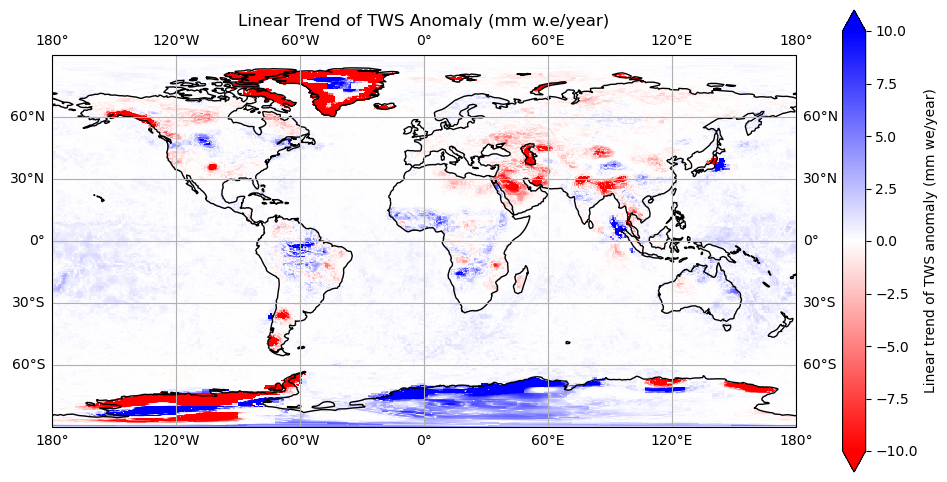

In [112]:
# Create figure and map projection (PlateCarree is lat/lon)
fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add coastlines and gridlines for context
ax.coastlines()
ax.gridlines(draw_labels=True)

# Plot the DataArray using pcolormesh with PlateCarree transform
im = mascon_approach_tws_change.plot.pcolormesh(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='bwr_r',  # diverging colormap, or RdBu_r
    vmin=-10,   # minimum value for colormap
    vmax=10,
    add_colorbar=True,
    cbar_kwargs={"label": mascon_approach_tws_change.attrs.get('description', '')}
)

# # Overlay the shapefile boundary
# for geom in hma_boundary.geometry:
#     ax.add_geometries([geom], crs=ccrs.PlateCarree(), edgecolor='black', linewidth=1.5, facecolor='none')

plt.title("Linear Trend of TWS Anomaly (mm w.e/year)")
plt.show()

In [130]:
#mascon_approach_tws_change.to_netcdf('delta_sigma_linear_trend_mm we_per_year_Mascon_Approach_VCE.nc')

import xarray as xr

mascon_approach_tws_change1 = xr.open_dataset(r'delta_sigma_linear_trend_mm we_per_year_Mascon_Approach_VCE.nc')
mascon_approach_tws_change1 #gives the true signal

<xarray.Dataset> Size: 2MB
Dimensions:       (lat: 360, lon: 720)
Coordinates:
  * lat           (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 88.5 89.0 89.5
  * lon           (lon) float64 6kB 0.0 0.5 1.0 1.5 ... 358.0 358.5 359.0 359.5
Data variables:
    linear_trend  (lat, lon) float64 2MB ...

## Truncated signal at 96 degree

In [121]:
# import xarray as xr

# delta_sigma_mascon_approach_with_love = xr.open_dataset(r'delta_sigma_with_love_mascon_approach_VCE.nc')
# delta_sigma_mascon_approach_with_love

import xarray as xr

# Replace 'filepath.nc' with the path to your NetCDF file
delta_sigma_mascon_approach_with_love = xr.open_dataset(r'D:/MSRSGI/Lab Rotation/Physical Geodesy/Python_Workspace/Organaized/Mascon/Combined/GIK_files/Thesisfiles/delta_sigma_with_love_mascon_approach_VCE.nc')
delta_sigma_mascon_approach_with_love

<xarray.Dataset> Size: 2MB
Dimensions:      (latitude: 360, longitude: 720)
Coordinates:
  * latitude     (latitude) float64 3kB -90.0 -89.5 -89.0 ... 88.5 89.0 89.5
  * longitude    (longitude) float64 6kB 0.0 0.5 1.0 1.5 ... 358.5 359.0 359.5
Data variables:
    delta_sigma  (latitude, longitude) float64 2MB ...

In [122]:
# Rename coordinates and variables in the Dataset
delta_sigma_mascon_approach_with_love_renamed = delta_sigma_mascon_approach_with_love.rename(
    {
        'latitude': 'lat',
        'longitude': 'lon',
        'delta_sigma': 'linear_trend' #in mm we/yr
    }
)

# Now print to check
delta_sigma_mascon_approach_with_love_renamed  #similar to the filter field in mm we/yr

<xarray.Dataset> Size: 2MB
Dimensions:       (lat: 360, lon: 720)
Coordinates:
  * lat           (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 88.5 89.0 89.5
  * lon           (lon) float64 6kB 0.0 0.5 1.0 1.5 ... 358.0 358.5 359.0 359.5
Data variables:
    linear_trend  (lat, lon) float64 2MB ...

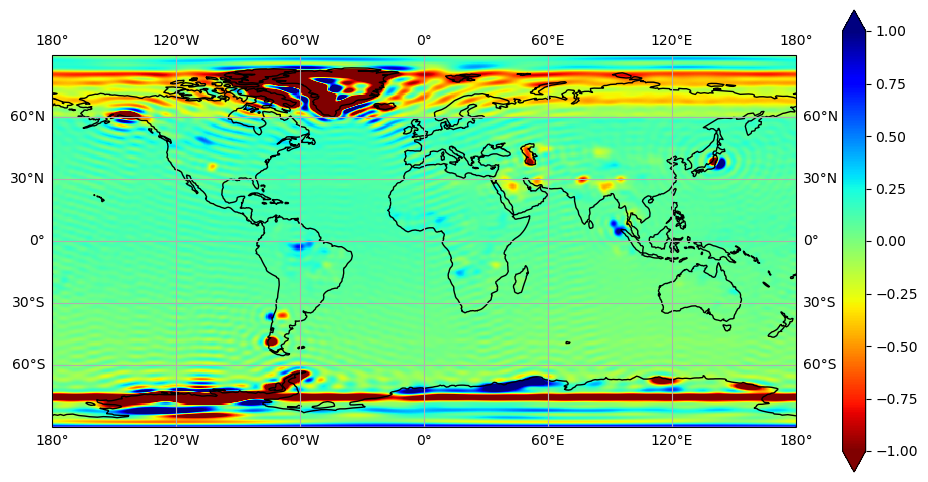

In [140]:
# Create figure and map projection (PlateCarree is lat/lon)
fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add coastlines and gridlines for context
ax.coastlines()
ax.gridlines(draw_labels=True)

# Plot the DataArray using pcolormesh with PlateCarree transform
im = delta_sigma_mascon_approach_with_love_renamed['linear_trend'].plot.pcolormesh(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='jet_r',  # diverging colormap, or RdBu_r
    vmin=-1,   # minimum value for colormap
    vmax=1,
    add_colorbar=True,
    cbar_kwargs={"label": delta_sigma_mascon_approach_with_love_renamed.attrs.get('description', '')}
)

# # Overlay the shapefile boundary
# for geom in hma_boundary.geometry:
#     ax.add_geometries([geom], crs=ccrs.PlateCarree(), edgecolor='black', linewidth=1.5, facecolor='none')

# plt.title("Linear Trend of TWS Anomaly (mm w.e/year)")
plt.show()

## Determination of the scale factor, Sf_for k :according to Vasaw Tripathi
We have griddded data in 2D, so have to do the elementwise division, maldivide operator in the least square sense is not possible

In [131]:
# mascon_approach_tws_change1 #gives the true signal
# delta_sigma_mascon_approach_with_love_renamed  #similar to the filter field in mm we/yr
gridded_scaling_factor = (mascon_approach_tws_change1['linear_trend'] / delta_sigma_mascon_approach_with_love_renamed['linear_trend'])
# Optionally reconstruct DataArray after subtraction:
gridded_scaling_factor_xr = xr.DataArray(
    gridded_scaling_factor,
    coords=mascon_approach_tws_change1['linear_trend'].coords,
    dims=mascon_approach_tws_change1['linear_trend'].dims,
    attrs=mascon_approach_tws_change1['linear_trend'].attrs
)
gridded_scaling_factor_xr

<xarray.DataArray 'linear_trend' (lat: 360, lon: 720)> Size: 2MB
array([[ 7.48460969,  7.46946026,  7.45398112, ...,  7.52825618,
         7.51399893,  7.49945362],
       [ 4.09687384,  4.02935212,  3.95981466, ...,  4.2874767 ,
         4.2259354 ,  4.16239923],
       [ 3.34551961,  3.37729972,  3.40954467, ...,  3.25287239,
         3.28331856,  3.31419615],
       ...,
       [ 0.61898976,  0.63344915,  0.64843542, ...,  2.22527571,
         2.27523566,  2.32701019],
       [ 3.07698   ,  3.23022626,  3.39725122, ..., 10.32889756,
        10.79160277, 11.29191736],
       [ 1.06195742,  1.0607593 ,  1.05963817, ...,  1.06599481,
         1.06457708,  1.06323064]], shape=(360, 720))
Coordinates:
  * lat      (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 88.0 88.5 89.0 89.5
  * lon      (lon) float64 6kB 0.0 0.5 1.0 1.5 2.0 ... 358.0 358.5 359.0 359.5
Attributes:
    description:  Linear trend of TWS anomaly (mm we/year)

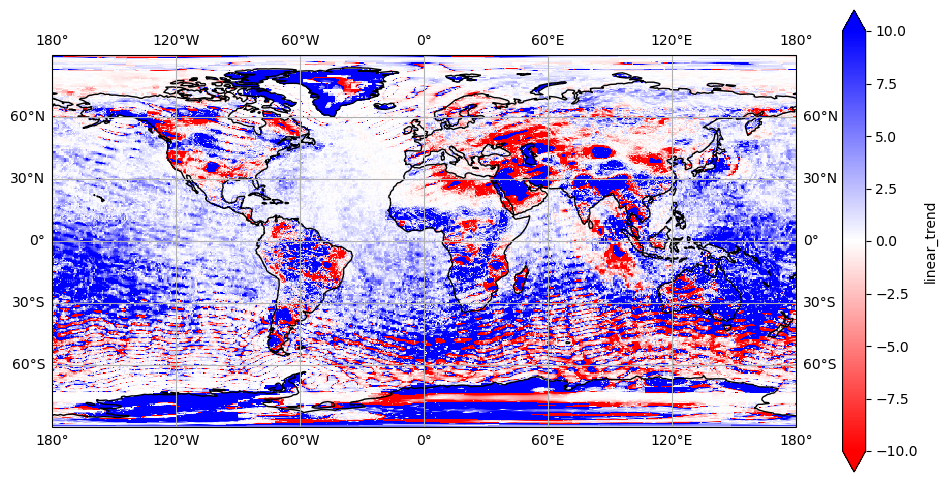

In [141]:
# Create figure and map projection (PlateCarree is lat/lon)
fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add coastlines and gridlines for context
ax.coastlines()
ax.gridlines(draw_labels=True)

# Plot the DataArray using pcolormesh with PlateCarree transform
im = gridded_scaling_factor_xr.plot.pcolormesh(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='bwr_r',  # diverging colormap, or RdBu_r
    vmin=-10,   # minimum value for colormap
    vmax=10,
    add_colorbar=True
    # cbar_kwargs={"label": gridded_scaling_factor_xr.attrs.get('description', '')}
)

# # Overlay the shapefile boundary
# for geom in hma_boundary.geometry:
#     ax.add_geometries([geom], crs=ccrs.PlateCarree(), edgecolor='black', linewidth=1.5, facecolor='none')

# plt.title("Linear Trend of TWS Anomaly (mm w.e/year)")
plt.show()

-------

In [145]:
# mascon_approach_tws_change1 #gives the true signal
# delta_sigma_mascon_approach_with_love_renamed  #similar to the filter field in mm we/yr

true_mass_rate_grid_mascon_approach = (gridded_scaling_factor_xr * delta_sigma_mascon_approach_with_love_renamed['linear_trend'])

# Optionally reconstruct DataArray after subtraction:
true_mass_rate_grid_mascon_approach_xr = xr.DataArray(
    true_mass_rate_grid_mascon_approach,
    coords=delta_sigma_mascon_approach_with_love_renamed['linear_trend'].coords,
    dims=delta_sigma_mascon_approach_with_love_renamed['linear_trend'].dims,
    attrs=delta_sigma_mascon_approach_with_love_renamed['linear_trend'].attrs
)
true_mass_rate_grid_mascon_approach_xr

<xarray.DataArray 'linear_trend' (lat: 360, lon: 720)> Size: 2MB
array([[ 5.88471487,  5.87280375,  5.8606334 , ...,  5.91903157,
         5.90782192,  5.89638579],
       [ 3.1223478 ,  3.07024836,  3.01658995, ...,  3.26935434,
         3.22190399,  3.17289914],
       [ 1.93933944,  1.9529103 ,  1.96655801, ...,  1.89905594,
         1.91241724,  1.92584304],
       ...,
       [ 0.07906139,  0.07906139,  0.07906139, ...,  0.30407435,
         0.30407435,  0.30407435],
       [ 0.07906139,  0.07906139,  0.07906139, ...,  0.30407435,
         0.30407435,  0.30407435],
       [-0.06209483, -0.06209483, -0.06209483, ..., -0.06209483,
        -0.06209483, -0.06209483]], shape=(360, 720))
Coordinates:
  * lat      (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 88.0 88.5 89.0 89.5
  * lon      (lon) float64 6kB 0.0 0.5 1.0 1.5 2.0 ... 358.0 358.5 359.0 359.5
Attributes:
    units:        kg/m^2
    description:  Surface density change

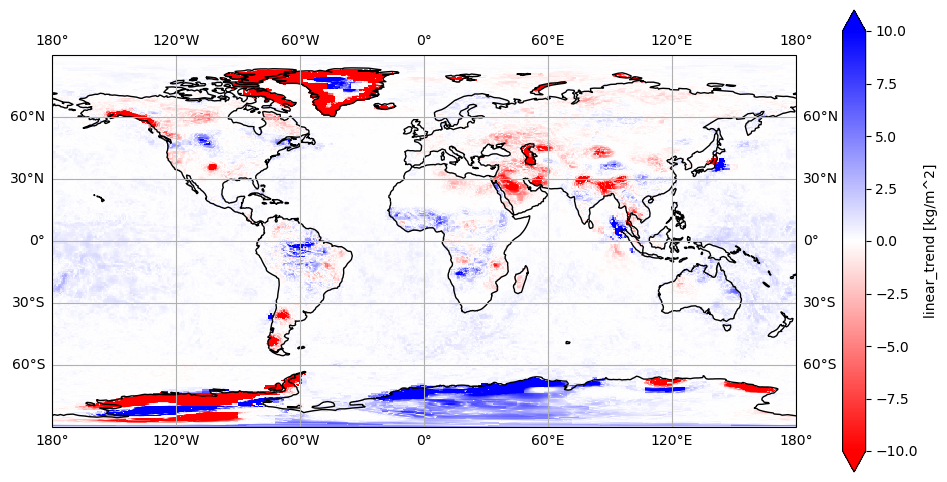

In [146]:
# Create figure and map projection (PlateCarree is lat/lon)
fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add coastlines and gridlines for context
ax.coastlines()
ax.gridlines(draw_labels=True)

# Plot the DataArray using pcolormesh with PlateCarree transform
im = true_mass_rate_grid_mascon_approach_xr.plot.pcolormesh(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='bwr_r',  # diverging colormap, or RdBu_r
    vmin=-10,   # minimum value for colormap
    vmax=10,
    add_colorbar=True
)

# plt.title("Linear Trend of TWS Anomaly (mm w.e/year)")
plt.show()